# Initial EDA: verified coworking locations in Lisbon

This notebook provides the initial exploratory analysis for the
Lisbon Coworking Market Opportunity Analysis. It inspects a frozen MVP
snapshot containing confirmed active coworking locations. The
original discovery and verification history remains in the wider
project datasets; this checkpoint focuses on a small, reproducible
table suitable for initial exploratory data analysis.

## 1. Imports and data loading

The CSV is loaded with a path relative to this notebook. The raw
checkpoint file is read only and is not overwritten.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/raw/coworking_locations_mvp_2026-07-25.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["collection_date"])

## 2. Basic structure

First, check the number of rows and columns, column names, data
types, and a small sample. Latitude and longitude should be numeric;
identifiers and descriptive fields should remain text.

In [2]:
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
df.head(5)

Shape: (48, 10)

Columns:
['coworking_id', 'coworking_name', 'latitude', 'longitude', 'parish', 'active_status', 'source_url', 'collection_date', 'source_type', 'verification_status']

Data types:
coworking_id                      str
coworking_name                    str
latitude                      float64
longitude                     float64
parish                            str
active_status                     str
source_url                        str
collection_date        datetime64[us]
source_type                       str
verification_status               str
dtype: object


,coworking_id,coworking_name,latitude,longitude,parish,active_status,source_url,collection_date,source_type,verification_status
0,osm_node_10011209150,Scape Workspaces,38.699587,-9.178883,Alcântara,active,https://www.openstreetmap.org/node/10011209150,2026-07-24,OpenStreetMap,verified_official_site
1,web_026,Spaces Alcântara,38.705806,-9.175569,Alcântara,active,https://www.spacesworks.com/en/pt/lisboa/sete-...,2026-07-24,official_operator_website,verified_official_site
2,osm_node_12709912384,AIhub by Unicorn Factory Lisboa,38.756565,-9.143440,Alvalade,active,https://www.openstreetmap.org/node/12709912384,2026-07-24,OpenStreetMap,verified_official_site
3,web_009,Heden Alvalade,38.756293,-9.141991,Alvalade,active,https://heden.co/about-heden-coworking/,2026-07-24,official_operator_website,verified_official_site
4,web_003,Kübe Coworking,38.756293,-9.141991,Alvalade,active,https://kubecoworking.pt/pages/sobre-nos,2026-07-24,official_operator_website,verified_official_site


## 3. Missing values and critical-column validation

For this checkpoint, `coworking_id`, `coworking_name`,
`active_status`, and `source_url` are critical. None of them should
be completely empty. Missing coordinates or parish values are kept
visible so they can be resolved in the next cleaning step.

In [3]:
critical_columns = [
    "coworking_id",
    "coworking_name",
    "active_status",
    "source_url",
]

missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(2))
)
display(missing_summary)

completely_empty_critical = [
    column for column in critical_columns if df[column].isna().all()
]
print("Completely empty critical columns:", completely_empty_critical)
assert not completely_empty_critical

,missing_count,missing_percent
coworking_id,0,0.0
coworking_name,0,0.0
latitude,0,0.0
longitude,0,0.0
parish,0,0.0
active_status,0,0.0
source_url,0,0.0
collection_date,0,0.0
source_type,0,0.0
verification_status,0,0.0


Completely empty critical columns: []


## 4. Descriptive statistics and category counts

Descriptive statistics summarise numeric coverage. Value counts show
how locations are distributed across parishes and source types.

In [4]:
display(df.describe(include="all").T)
display(df["parish"].value_counts(dropna=False).rename("location_count").to_frame())
display(df["source_type"].value_counts(dropna=False).rename("location_count").to_frame())

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
coworking_id,48,48,osm_node_10011209150,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coworking_name,48,46,Avila Spaces,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48.0,NaN,NaN,NaN,38.730222,38.699587,38.717021,38.723947,38.744306,38.771402,0.019012
longitude,48.0,NaN,NaN,NaN,-9.146222,-9.208741,-9.154152,-9.144568,-9.139586,-9.097108,0.022603
parish,48,14,Santo António,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_status,48,1,active,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_url,48,40,https://www.spacesworks.com/en/pt/lisboa/sete-...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collection_date,48,NaN,NaN,NaN,2026-07-24 00:00:00,2026-07-24 00:00:00,2026-07-24 00:00:00,2026-07-24 00:00:00,2026-07-24 00:00:00,2026-07-24 00:00:00,NaN
source_type,48,3,OpenStreetMap,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
verification_status,48,1,verified_official_site,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,location_count
parish,
Santo António,9
Arroios,7
Santa Maria Maior,6
Alvalade,4
Avenidas Novas,4
Campo de Ourique,3
Parque das Nações,3
São Domingos de Benfica,3
Alcântara,2


,location_count
source_type,
OpenStreetMap,21
official_operator_website,19
OpenStreetMap + official operator website,8


## 5. Duplicate checks

Exact duplicate rows and repeated IDs would invalidate location
counts. A second check flags records sharing the same name and
coordinates, which can reveal branches imported twice.

In [5]:
exact_duplicate_rows = int(df.duplicated().sum())
duplicate_ids = int(df["coworking_id"].duplicated().sum())
duplicate_name_coordinates = int(
    df.duplicated(subset=["coworking_name", "latitude", "longitude"]).sum()
)

print("Exact duplicate rows:", exact_duplicate_rows)
print("Duplicate coworking IDs:", duplicate_ids)
print("Duplicate name-coordinate combinations:", duplicate_name_coordinates)

Exact duplicate rows: 0
Duplicate coworking IDs: 0
Duplicate name-coordinate combinations: 0


## 6. Simple visualisation

The chart is an initial view of observed coworking competition by
parish. It is not yet an opportunity ranking: population, transport,
rents, and other demand indicators will be joined later.

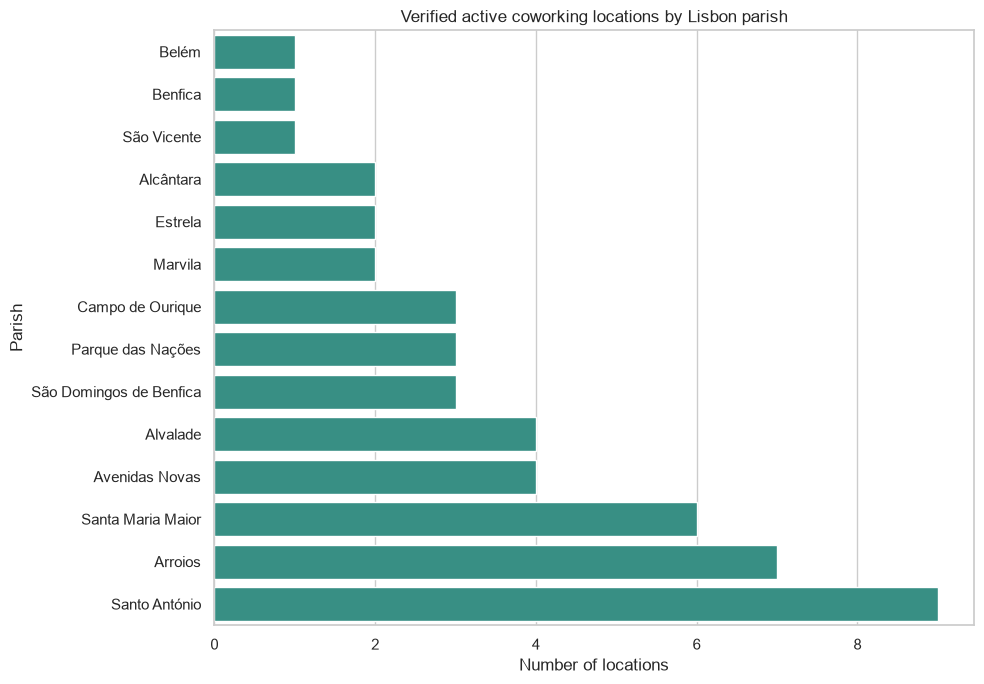

In [6]:
parish_counts = (
    df["parish"]
    .fillna("Parish not yet assigned")
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=parish_counts.values, y=parish_counts.index, color="#2A9D8F")
plt.title("Verified active coworking locations by Lisbon parish")
plt.xlabel("Number of locations")
plt.ylabel("Parish")
plt.tight_layout()
plt.show()

## 7. Initial data-quality observations

1. The checkpoint contains **48 confirmed active locations**, and
   all critical identification and source fields are populated.
2. **Latitude, longitude, and parish are complete for all 48
   locations** after address verification and geocoding against
   official operator information and OpenStreetMap building points.
3. There are **no exact duplicate rows and no duplicate IDs** in
   this frozen snapshot. Name-and-coordinate matches are also
   checked because the same operator can legitimately have several
   Lisbon branches.
4. `active_status` and `verification_status` have one value by
   design: this MVP is a verified-active analysis subset, not the
   full candidate history. Closed and excluded candidates remain in
   the processed audit table.

The next technical step is to join these complete location counts
to the 24-row parish indicators table and continue the full EDA.